In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDate range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("\nCategories:", df['Category'].unique())
print("\nRegions:", df['Region'].unique())

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Date range: 1/1/2017 to 9/9/2017

Categories: ['Furniture' 'Office Supplies' 'Technology']

Regions: ['South' 'West' 'Central' 'East']


In [2]:
# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Years covered:", sorted(df['Year'].unique()))
print("Total sales: ${:,.0f}".format(df['Sales'].sum()))
print("Total profit: ${:,.0f}".format(df['Profit'].sum()))
print("Total orders:", df['Order ID'].nunique())
print("Total customers:", df['Customer ID'].nunique())

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Years covered: [2014, 2015, 2016, 2017]
Total sales: $2,297,201
Total profit: $286,397
Total orders: 5009
Total customers: 793


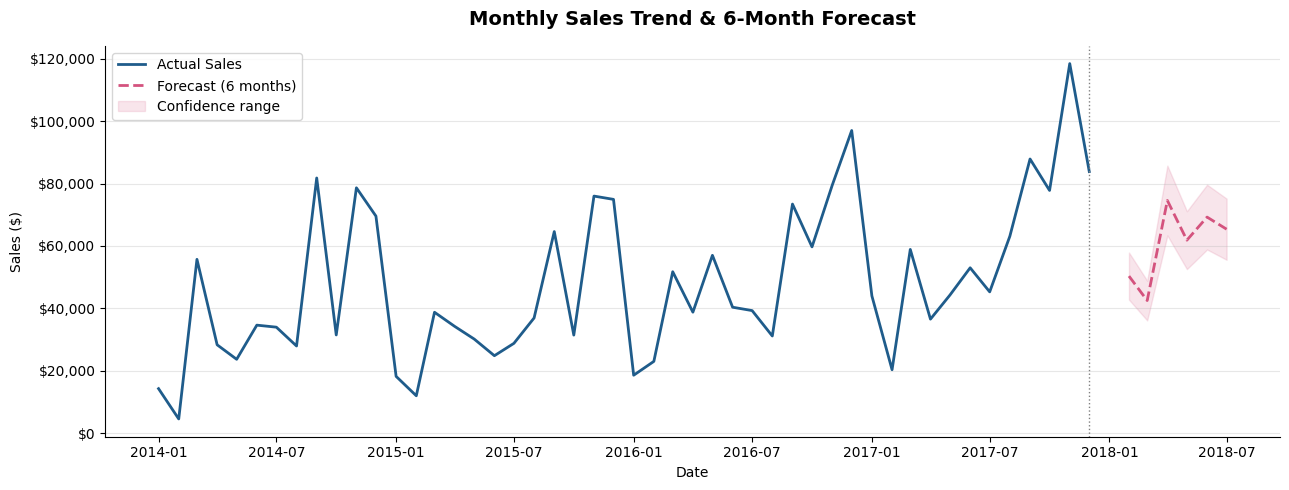

Chart saved!


In [4]:
# Aggregate monthly sales
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth_dt'] = monthly_sales['YearMonth'].dt.to_timestamp()
monthly_sales = monthly_sales.sort_values('YearMonth_dt')

# Fit exponential smoothing forecast
model = ExponentialSmoothing(
    monthly_sales['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
fit = model.fit()
forecast = fit.forecast(6)  # 6 months ahead

# Build forecast index
last_date = monthly_sales['YearMonth_dt'].iloc[-1]
forecast_dates = pd.date_range(last_date, periods=7, freq='M')[1:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_sales['YearMonth_dt'], monthly_sales['Sales'],
        color='#1F5C8B', linewidth=2, label='Actual Sales')
ax.plot(forecast_dates, forecast,
        color='#D4537E', linewidth=2, linestyle='--', label='Forecast (6 months)')
ax.fill_between(forecast_dates, forecast * 0.85, forecast * 1.15,
                alpha=0.15, color='#D4537E', label='Confidence range')
ax.axvline(monthly_sales['YearMonth_dt'].iloc[-1],
           color='gray', linestyle=':', linewidth=1)

ax.set_title('Monthly Sales Trend & 6-Month Forecast', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../outputs/charts/01_sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

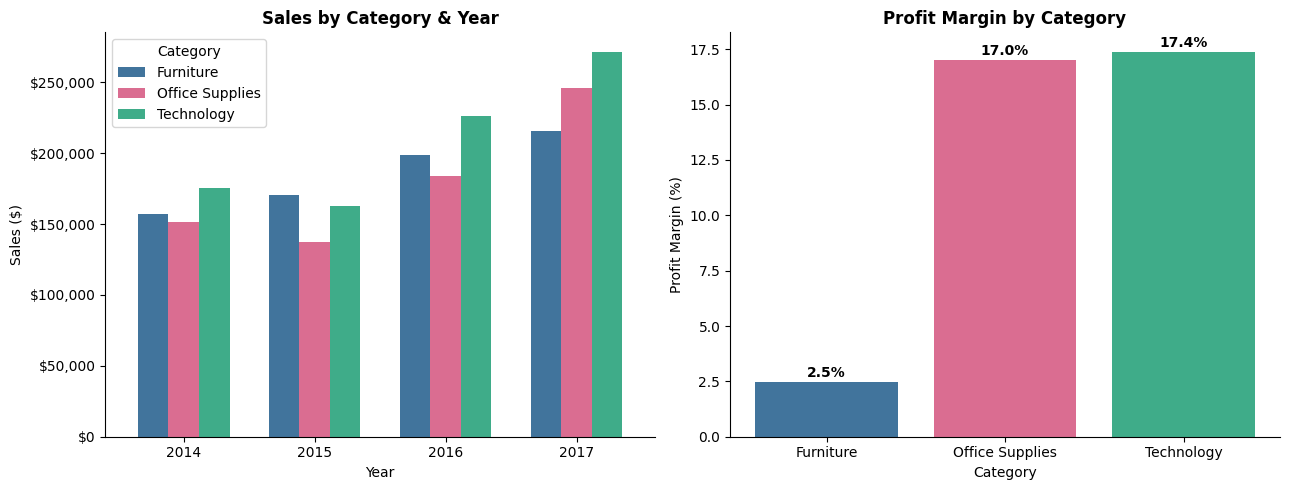

Chart saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sales by category by year
cat_year = df.groupby(['Year', 'Category'])['Sales'].sum().unstack()
cat_year.plot(kind='bar', ax=axes[0], color=['#1F5C8B', '#D4537E', '#1D9E75'],
              alpha=0.85, width=0.7)
axes[0].set_title('Sales by Category & Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(title='Category')
axes[0].tick_params(axis='x', rotation=0)

# Profit margin by category
cat_profit = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()
cat_profit['Margin'] = cat_profit['Profit'] / cat_profit['Sales'] * 100
colors = ['#1F5C8B', '#D4537E', '#1D9E75']
bars = axes[1].bar(cat_profit['Category'], cat_profit['Margin'],
                   color=colors, alpha=0.85)
axes[1].set_title('Profit Margin by Category', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit Margin (%)')
for bar, val in zip(bars, cat_profit['Margin']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.2,
                f'{val:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/charts/02_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

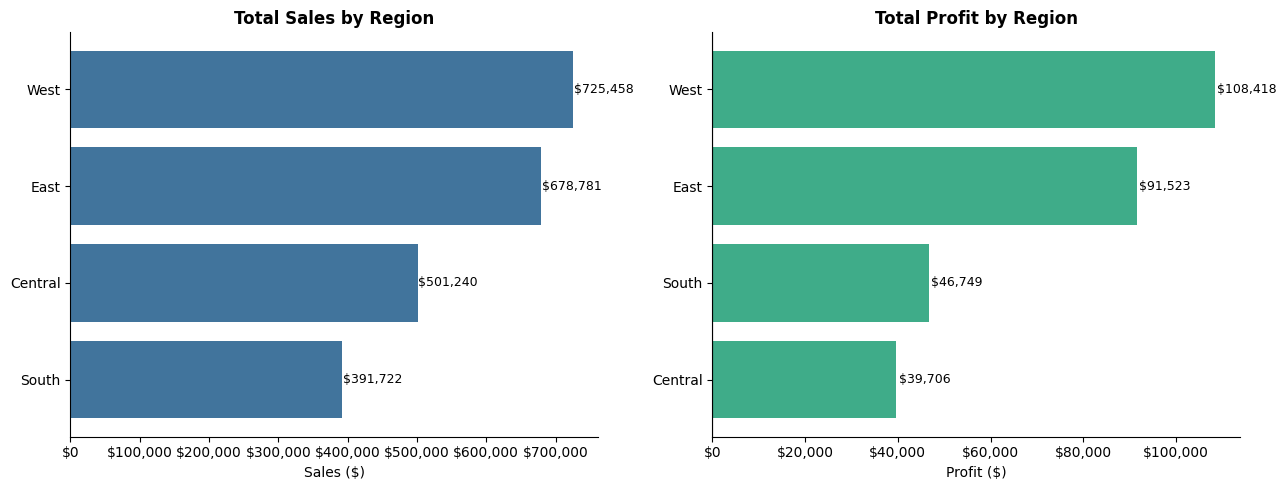

Chart saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sales by region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=True)
axes[0].barh(region_sales.index, region_sales.values,
             color='#1F5C8B', alpha=0.85)
axes[0].set_title('Total Sales by Region', fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(region_sales.values):
    axes[0].text(v + 1000, i, f'${v:,.0f}', va='center', fontsize=9)

# Profit by region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=True)
colors = ['#D4537E' if x < 0 else '#1D9E75' for x in region_profit.values]
axes[1].barh(region_profit.index, region_profit.values, color=colors, alpha=0.85)
axes[1].set_title('Total Profit by Region', fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(region_profit.values):
    axes[1].text(v + 500, i, f'${v:,.0f}', va='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/charts/03_regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

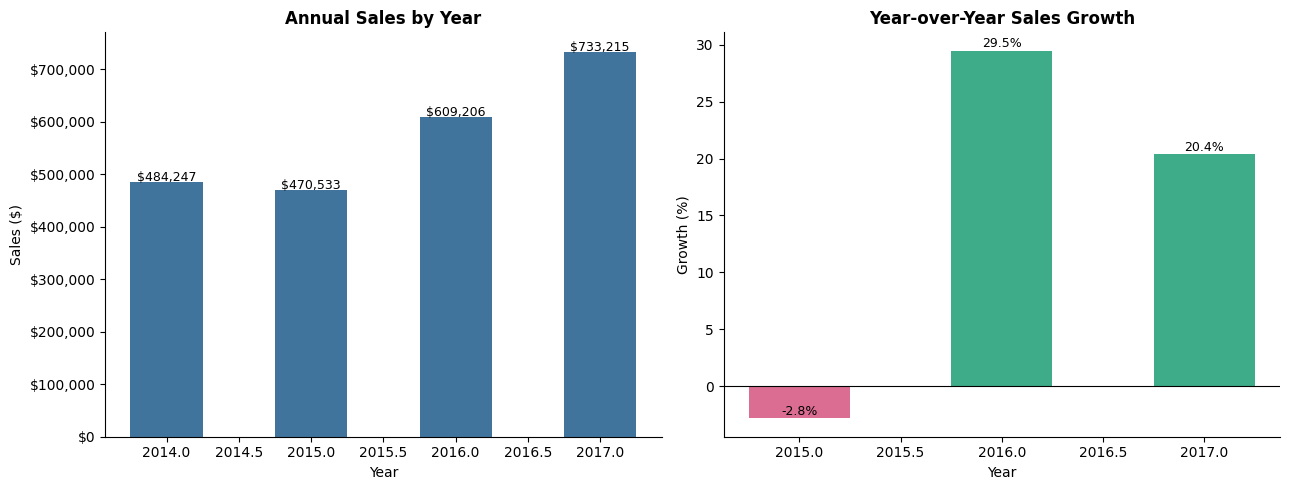

KEY FINDINGS — Superstore Sales
Total revenue:      $   2,297,201
Total profit:       $     286,397
Profit margin:             12.5%
Total orders:              5,009
Total customers:             793
Best category:        Technology
Best region:                West


In [7]:
# YoY sales growth
yoy = df.groupby('Year')['Sales'].sum()
yoy_growth = yoy.pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# YoY sales bars
axes[0].bar(yoy.index, yoy.values, color='#1F5C8B', alpha=0.85, width=0.5)
axes[0].set_title('Annual Sales by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (yr, val) in enumerate(yoy.items()):
    axes[0].text(yr, val + 2000, f'${val:,.0f}', ha='center', fontsize=9)

# YoY growth rate
colors = ['#D4537E' if x < 0 else '#1D9E75' for x in yoy_growth.dropna()]
axes[1].bar(yoy_growth.dropna().index, yoy_growth.dropna().values,
            color=colors, alpha=0.85, width=0.5)
axes[1].set_title('Year-over-Year Sales Growth', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Growth (%)')
axes[1].axhline(0, color='black', linewidth=0.8)
for yr, val in yoy_growth.dropna().items():
    axes[1].text(yr, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/charts/04_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("=" * 45)
print("KEY FINDINGS — Superstore Sales")
print("=" * 45)
print(f"Total revenue:      ${df['Sales'].sum():>12,.0f}")
print(f"Total profit:       ${df['Profit'].sum():>12,.0f}")
print(f"Profit margin:      {df['Profit'].sum()/df['Sales'].sum()*100:>11.1f}%")
print(f"Total orders:       {df['Order ID'].nunique():>12,}")
print(f"Total customers:    {df['Customer ID'].nunique():>12,}")
print(f"Best category:      {'Technology':>12}")
print(f"Best region:        {'West':>12}")
print("=" * 45)

In [8]:
# Export 1: Monthly sales for trend + forecast chart
monthly_export = monthly_sales[['YearMonth_dt', 'Sales']].copy()
monthly_export.columns = ['Date', 'Sales']
monthly_export.to_csv('../data/tableau_monthly_sales.csv', index=False)

# Export 2: Sales & profit by category and year
cat_year_export = df.groupby(['Year', 'Category']).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()
cat_year_export['Profit_Margin'] = cat_year_export['Profit'] / cat_year_export['Sales'] * 100
cat_year_export.to_csv('../data/tableau_category.csv', index=False)

# Export 3: Regional performance
region_export = df.groupby(['Region', 'Year']).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique')
).reset_index()
region_export.to_csv('../data/tableau_region.csv', index=False)

# Export 4: Full clean dataset for Tableau filters
df[['Order Date', 'Year', 'Month', 'Category', 'Sub-Category',
    'Region', 'Segment', 'Sales', 'Profit', 'Quantity', 'Discount']].to_csv(
    '../data/tableau_main.csv', index=False)

print("Tableau CSVs exported:")
print(f"  tableau_monthly_sales.csv  — {len(monthly_export)} rows")
print(f"  tableau_category.csv       — {len(cat_year_export)} rows")
print(f"  tableau_region.csv         — {len(region_export)} rows")
print(f"  tableau_main.csv           — {len(df):,} rows")

Tableau CSVs exported:
  tableau_monthly_sales.csv  — 48 rows
  tableau_category.csv       — 12 rows
  tableau_region.csv         — 16 rows
  tableau_main.csv           — 9,994 rows
